# 04. Fraud claims versus fraud flags, and NLP over the call transcripts

Two questions from the team (28-Sep):

1. **Data issue check.** How many transactions are claimed as fraud by customers (complaints table) versus how many carry the `is_fraud` flag, and do the two populations touch each other at all?
2. **NLP on the call transcripts.** Is there anything fraud related in what customers say on the phone that could enrich the model's data?

Everything here is aggregate: no customer row, no free text row is printed. Text is analyzed as vocabulary, template counts and lexicon hits.

Sources: `data/lakehouse_full.duckdb` (silver complaints, silver and gold transactions, 2023 to 2026) and `data/lakehouse_aux.duckdb` (call center interactions, call transcripts, satisfaction surveys, last 12 months plus history where loaded).

In [1]:
import re, json, warnings, collections
from pathlib import Path
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": "#e6e5e1", "font.size": 9})
BLUE, ORANGE, RED, GRAY, GREEN = "#2a78d6", "#eb6834", "#e34948", "#8a8985", "#2e9e6b"
FULL, AUX = Path("data/lakehouse_full.duckdb"), Path("data/lakehouse_aux.duckdb")
con = duckdb.connect(str(FULL), read_only=True)
con.execute(f"ATTACH '{AUX}' AS aux (READ_ONLY)")
q = lambda sql: con.execute(sql).df()
print("transactions:", con.execute("select count(*) from silver_transactions").fetchone()[0])
print("complaints:", con.execute("select count(*) from silver_complaints").fetchone()[0])
print("transcripts:", con.execute("select count(*) from aux.call_transcripts").fetchone()[0])

transactions: 4425008
complaints: 67095
transcripts: 171321


## Part A. Fraud claims versus fraud flags

The complaints table is the only place where a customer claims a charge. The subcategory `Cargo no reconocido` (unrecognized charge) under category `Transactions` is the claim of fraud in this dataset. The transactions table carries the bank's own flag `is_fraud`.

### A1. Volumes per year

In [2]:
flags = q("select year, sum(is_fraud::int)::int fraud_flags, count(*) tx from silver_transactions group by 1 order by 1")
claims = q("""select year, sum((subcategory='Cargo no reconocido')::int)::int unrecognized_charge,
                sum((category='Transactions')::int)::int transactions_category, count(*) complaints
              from silver_complaints group by 1 order by 1""")
vol = flags.merge(claims, on="year")
vol["claims_per_flag"] = (vol["unrecognized_charge"] / vol["fraud_flags"]).round(2)
print(vol.to_string(index=False))
print(f"\nTotal: {vol.fraud_flags.sum():,} fraud flags, {vol.unrecognized_charge.sum():,} unrecognized-charge claims, "
      f"{vol.transactions_category.sum():,} complaints in the Transactions category, {vol.complaints.sum():,} complaints of any kind.")

 year  fraud_flags      tx  unrecognized_charge  transactions_category  complaints  claims_per_flag
 2023          814  801170                 2201                   2420       12078             2.70
 2024         1485 1471814                 4051                   4497       22329             2.73
 2025         1414 1466502                 4123                   4570       22356             2.92
 2026          603  685522                 1922                   2093       10332             3.19

Total: 4,316 fraud flags, 12,297 unrecognized-charge claims, 13,580 complaints in the Transactions category, 67,095 complaints of any kind.


Claims outnumber flags about three to one in every year, and the ratio is stable. That alone is not a data issue (most disputes are not fraud, and most fraud is never disputed), but it tells us the two counts are generated independently. The next checks test whether they touch.

### A2. Complaint categories are uniform

If claims reflected real events, transaction complaints would concentrate on customers and products with problems. Instead every category and subcategory has the same volume, the description field has five templates, and no complaint links to an interaction.

In [3]:
cat = q("""select category, count(*) n, count(distinct subcategory) subcategories,
              sum(affected_product_id is null)::int no_product, sum(claimed_amount is null)::int no_amount,
              sum(origin_interaction_id is not null)::int with_interaction
            from silver_complaints group by 1 order by 1""")
print(cat.to_string(index=False))
desc = q("select count(distinct description) distinct_descriptions, round(avg(length(description))) avg_length from silver_complaints")
print("\ndescription field:", desc.iloc[0].to_dict())
FRAUD_LEXICON = r"fraud|fraude|robo|robad|clon|no reconozco|não reconheço|nao reconheco|desconoc|estafa|phishing|no autoric|não autoriz|nao autoriz|cargo no reconocido|golpe"
hits = con.execute(f"select sum(regexp_matches(lower(description), '{FRAUD_LEXICON}')::int) from silver_complaints").fetchone()[0]
print("complaint descriptions with any fraud word:", int(hits or 0))

    category     n  subcategories  no_product  no_amount  with_interaction
      Branch 13361              1        4553       9138                 0
        Fees 13553              1        4534       9096                 0
     Service 13194              1        4357       8975                 0
   Technical 13407              1        4502       9055                 0
Transactions 13580              1        4579       9080                 0

description field: {'distinct_descriptions': 5.0, 'avg_length': 30.0}
complaint descriptions with any fraud word: 0


### A3. Do fraud flags lead to claims?

For every flagged charge, and for a 1 percent sample of unflagged charges, count how often the same customer files a complaint in the 60 days after the charge (the dispute window), by complaint kind, and how often the complaint names the same product.

In [4]:
link = q("""
with tx as (select transaction_id, customer_id, product_id, process_date, is_fraud
            from silver_transactions where is_fraud or hash(transaction_id) % 100 = 0),
c as (select customer_id, affected_product_id, process_date cdate, category, subcategory from silver_complaints)
select is_fraud, count(*) charges,
  sum(exists(select 1 from c where c.customer_id=tx.customer_id and c.cdate between tx.process_date and tx.process_date+60))::int any_complaint,
  sum(exists(select 1 from c where c.customer_id=tx.customer_id and c.category='Transactions' and c.cdate between tx.process_date and tx.process_date+60))::int transactions_complaint,
  sum(exists(select 1 from c where c.customer_id=tx.customer_id and c.subcategory='Cargo no reconocido' and c.cdate between tx.process_date and tx.process_date+60))::int unrecognized_claim,
  sum(exists(select 1 from c where c.affected_product_id=tx.product_id and c.subcategory='Cargo no reconocido' and c.cdate between tx.process_date and tx.process_date+60))::int unrecognized_same_product
from tx group by 1 order by 1""")
for col in ["any_complaint", "transactions_complaint", "unrecognized_claim", "unrecognized_same_product"]:
    link[col + "_pct"] = (100 * link[col] / link["charges"]).round(2)
print(link.to_string(index=False))
# Fisher exact test on unrecognized claims: flagged vs unflagged charges
a = link.set_index("is_fraud")
table = [[int(a.loc[True, "unrecognized_claim"]), int(a.loc[True, "charges"] - a.loc[True, "unrecognized_claim"])],
         [int(a.loc[False, "unrecognized_claim"]), int(a.loc[False, "charges"] - a.loc[False, "unrecognized_claim"])]]
odds, p = stats.fisher_exact(table)
print(f"\nFisher exact, unrecognized claim within 60 days after a flagged vs unflagged charge: odds ratio {odds:.2f}, p = {p:.3f}")

 is_fraud  charges  any_complaint  transactions_complaint  unrecognized_claim  unrecognized_same_product  any_complaint_pct  transactions_complaint_pct  unrecognized_claim_pct  unrecognized_same_product_pct
    False    44171           1048                     216                 200                         49               2.37                        0.49                    0.45                           0.11
     True     4316             78                      16                  15                          6               1.81                        0.37                    0.35                           0.14

Fisher exact, unrecognized claim within 60 days after a flagged vs unflagged charge: odds ratio 0.77, p = 0.400


### A4. Do claims point back to flags?

The mirror check: for every complaint, did the customer have a flagged charge in the 60 days before the complaint? If claims reflected fraud, the unrecognized-charge subcategory would stand out against the other categories.

In [5]:
back = q("""
with f as (select customer_id, product_id, process_date fdate from silver_transactions where is_fraud)
select category, coalesce(subcategory, '(none)') subcategory, count(*) complaints,
  sum(exists(select 1 from f where f.customer_id=c.customer_id and f.fdate between c.process_date-60 and c.process_date))::int flag_before,
  sum(exists(select 1 from f where f.product_id=c.affected_product_id and f.fdate between c.process_date-60 and c.process_date))::int flag_same_product
from silver_complaints c group by 1,2 order by 1,2""")
back["flag_before_pct"] = (100 * back["flag_before"] / back["complaints"]).round(2)
print(back.to_string(index=False))
chi2, p, _, _ = stats.chi2_contingency(back[["flag_before", "complaints"]].assign(rest=lambda d: d.complaints - d.flag_before)[["flag_before", "rest"]].values)
print(f"\nChi-square across the 10 complaint kinds: chi2 = {chi2:.1f}, p = {p:.3f}")

    category          subcategory  complaints  flag_before  flag_same_product  flag_before_pct
      Branch               (none)        1469            3                  0             0.20
      Branch Atención en sucursal       11892           12                  3             0.10
        Fees               (none)        1359            3                  0             0.22
        Fees       Cobro indebido       12194           17                  7             0.14
     Service               (none)        1308            2                  0             0.15
     Service  Calidad de servicio       11886           14                  3             0.12
   Technical               (none)        1279            2                  0             0.16
   Technical     Problema con app       12128           10                 10             0.08
Transactions               (none)        1283            1                  0             0.08
Transactions  Cargo no reconocido       12297     

### A5. Customer level and amount level

Two last angles. Customers who ever had a flagged charge: do they file more unrecognized-charge claims than customers who never had one? And for the few claims that name the same product as a flagged charge in the window, does the claimed amount match the charge?

In [6]:
cust = q("""
with fc as (select customer_id, sum(is_fraud::int) flags from silver_transactions group by 1),
cc as (select customer_id, sum((subcategory='Cargo no reconocido')::int) unrec, count(*) complaints from silver_complaints group by 1)
select (flags>0) has_fraud_flag, count(*) customers,
  round(avg(coalesce(unrec,0)),4) unrecognized_claims_per_customer, round(avg(coalesce(complaints,0)),4) complaints_per_customer,
  round(100.0*avg((coalesce(unrec,0)>0)::int),2) pct_with_unrecognized_claim
from fc left join cc using(customer_id) group by 1 order by 1""")
print(cust.to_string(index=False))
amt = q("""
select count(*) linked_claims, sum((abs(c.claimed_amount-t.amount)<1)::int) amount_matches, sum((c.currency=t.currency)::int) same_currency
from silver_complaints c join silver_transactions t
  on t.product_id=c.affected_product_id and t.is_fraud and t.process_date between c.process_date-60 and c.process_date
where c.subcategory='Cargo no reconocido' and c.claimed_amount is not null""")
print("\nclaims naming the product of a flagged charge in the window:", amt.iloc[0].to_dict())

 has_fraud_flag  customers  unrecognized_claims_per_customer  complaints_per_customer  pct_with_unrecognized_claim
          False     130282                            0.0825                   0.4498                         7.92
           True       4233                            0.0808                   0.4522                         7.96

claims naming the product of a flagged charge in the window: {'linked_claims': 3.0, 'amount_matches': 0.0, 'same_currency': 0.0}


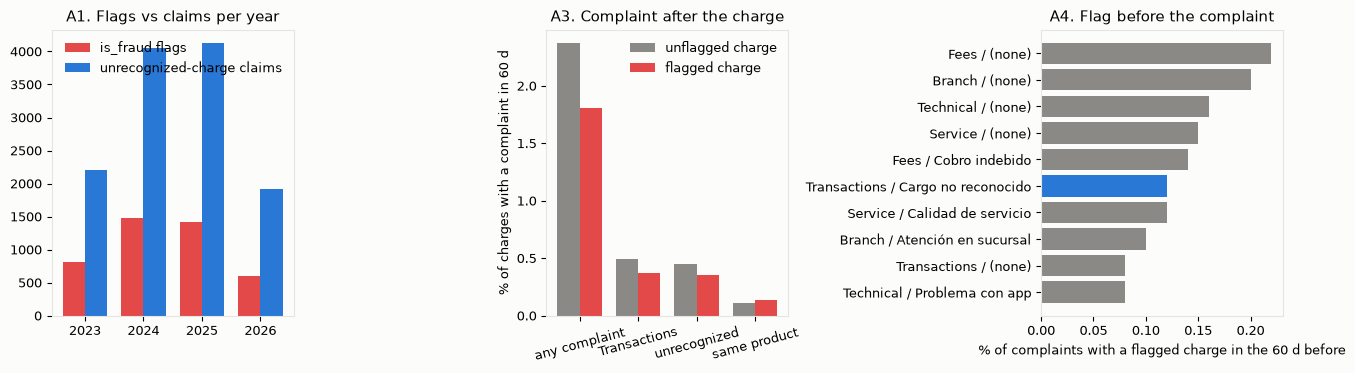

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
ax = axes[0]
x = np.arange(len(vol)); w = 0.38
ax.bar(x - w/2, vol.fraud_flags, w, color=RED, label="is_fraud flags")
ax.bar(x + w/2, vol.unrecognized_charge, w, color=BLUE, label="unrecognized-charge claims")
ax.set_xticks(x); ax.set_xticklabels([str(y) for y in vol.year]); ax.set_title("A1. Flags vs claims per year"); ax.legend(frameon=False)
ax = axes[1]
lab = ["any complaint", "Transactions", "unrecognized", "same product"]
cols = ["any_complaint_pct", "transactions_complaint_pct", "unrecognized_claim_pct", "unrecognized_same_product_pct"]
x = np.arange(4)
ax.bar(x - w/2, a.loc[False, cols].values, w, color=GRAY, label="unflagged charge")
ax.bar(x + w/2, a.loc[True, cols].values, w, color=RED, label="flagged charge")
ax.set_xticks(x); ax.set_xticklabels(lab, rotation=15); ax.set_ylabel("% of charges with a complaint in 60 d"); ax.set_title("A3. Complaint after the charge"); ax.legend(frameon=False)
ax = axes[2]
bb = back.sort_values("flag_before_pct")
ax.barh(bb.category + " / " + bb.subcategory, bb.flag_before_pct, color=[BLUE if s == "Cargo no reconocido" else GRAY for s in bb.subcategory])
ax.set_xlabel("% of complaints with a flagged charge in the 60 d before"); ax.set_title("A4. Flag before the complaint")
plt.tight_layout(); plt.savefig("notebooks/16_claims_vs_flags.png", dpi=130); plt.show()

**Part A verdict.** Claims and flags do not touch. A flagged charge is not followed by a claim more often than an unflagged one (if anything less), the unrecognized-charge subcategory does not carry more flagged charges before it than branch or service complaints, customers with flags claim at the same rate as customers without, and the handful of claims that name the product of a flagged charge never match its amount or currency. Complaint categories are uniform, descriptions are five templates, and `origin_interaction_id` is empty everywhere. The `is_fraud` flag and the complaints table were generated independently; neither is derived from customer behavior. This is a data issue for any supervised model and for any "claim rate" metric, and it is the same independence already seen in notebooks 02 and 03 (TQ-023).

## Part B. NLP over the call transcripts

### B1. What the transcripts contain

In [8]:
inv = q("""select count(*) transcripts, count(distinct customer_id) customers, count(distinct detected_language) languages,
              count(distinct customer_text) distinct_customer_texts, count(distinct agent_text) distinct_agent_texts,
              count(distinct full_text) distinct_full_texts, count(distinct detected_intents) distinct_intents,
              count(distinct main_topics) distinct_topics, count(distinct detected_keywords) distinct_keyword_sets,
              round(avg(length(customer_text))) avg_customer_chars, min(length(customer_text)) min_chars, max(length(customer_text)) max_chars
            from aux.call_transcripts""")
print(inv.T.to_string(header=False))
print()
print(q("select main_topics, count(*) transcripts, count(distinct customer_text) distinct_customer_texts from aux.call_transcripts group by 1 order by 2 desc").to_string(index=False))
print()
print(q("select coalesce(detected_intents,'(null)') detected_intents, count(*) n from aux.call_transcripts group by 1 order by 2 desc").to_string(index=False))

transcripts              171321.0
customers                101951.0
languages                     1.0
distinct_customer_texts      42.0
distinct_agent_texts         42.0
distinct_full_texts         546.0
distinct_intents              1.0
distinct_topics               6.0
distinct_keyword_sets        12.0
avg_customer_chars           94.0
min_chars                    68.0
max_chars                   162.0

  main_topics  transcripts  distinct_customer_texts
Transaccional        59786                       42
     Producto        37658                       42
        Queja        29198                       42
      Técnico        25691                       42
    Comercial        13808                       42
    Retención         5180                       42

detected_intents      n
consulta_general 162864
          (null)   8457


### B2. Vocabulary and TF-IDF terms per topic

The distinct customer texts are the corpus (each weighted by how many calls carry it). With 42 templates the vocabulary is tiny; TF-IDF per topic shows whether any topic has words about charges, cards, theft or fraud.

In [9]:
tmpl = q("select customer_text, main_topics, count(*) n from aux.call_transcripts where customer_text is not null group by 1,2")
docs = tmpl.customer_text.tolist()
vec = TfidfVectorizer(token_pattern=r"[a-záéíóúñü]{3,}", lowercase=True)
X = vec.fit_transform(docs); vocab = np.array(vec.get_feature_names_out())
print("vocabulary size (words of 3+ letters):", len(vocab))
print("full vocabulary:", ", ".join(sorted(vocab)))
print()
for topic, g in tmpl.groupby("main_topics"):
    idx = g.index.values; wts = g.n.values
    mean = np.asarray(X[idx].multiply(wts[:, None]).sum(axis=0)).ravel() / wts.sum()
    top = vocab[np.argsort(-mean)[:8]]
    print(f"{topic:14s} ({g.n.sum():6,} calls, {len(g)} templates): {', '.join(top)}")

vocabulary size (words of 3+ letters): 32
full vocabulary: actual, ahorros, algo, bien, buenas, buenos, consultar, crédito, cuenta, cuál, cuánto, deba, días, entiendo, eso, gracias, hay, hola, muchas, muy, más, necesitaba, necesito, perfecto, que, quisiera, saber, saldo, tarda, tardes, tarjeta, tiempo

Comercial      (13,808 calls, 42 templates): saldo, tardes, tarjeta, buenas, consultar, crédito, necesito, hola
Producto       (37,658 calls, 42 templates): saldo, tarjeta, tardes, buenas, consultar, crédito, necesito, actual
Queja          (29,198 calls, 42 templates): saldo, tarjeta, tardes, buenas, consultar, crédito, necesito, actual
Retención      ( 5,180 calls, 42 templates): saldo, tardes, buenas, tarjeta, consultar, crédito, necesito, actual
Transaccional  (59,786 calls, 42 templates): saldo, tarjeta, tardes, buenas, consultar, crédito, necesito, actual
Técnico        (25,691 calls, 42 templates): saldo, tarjeta, tardes, buenas, consultar, crédito, necesito, actual


### B3. Fraud lexicon over every free-text field

A Spanish and Portuguese fraud lexicon (fraud, theft, cloning, unrecognized, unauthorized, scam, phishing) applied to the customer text, the agent text, the full transcript, the dataset's own keyword field, the complaint descriptions and the survey comments.

In [10]:
LEX = FRAUD_LEXICON
rows = []
for name, table, col in [("transcript customer_text", "aux.call_transcripts", "customer_text"), ("transcript agent_text", "aux.call_transcripts", "agent_text"),
                         ("transcript full_text", "aux.call_transcripts", "full_text"), ("transcript detected_keywords", "aux.call_transcripts", "detected_keywords"),
                         ("complaint description", "silver_complaints", "description"), ("survey open_comments", "aux.satisfaction_surveys", "open_comments")]:
    r = con.execute(f"select count(*) n, sum({col} is not null)::int filled, count(distinct {col}) distinct_values, "
                    f"coalesce(sum(regexp_matches(lower({col}), '{LEX}')::int),0) fraud_hits from {table}").fetchone()
    rows.append((name, *r))
lex = pd.DataFrame(rows, columns=["field", "rows", "filled", "distinct_values", "fraud_hits"])
print(lex.to_string(index=False))
# broader lexicon: anything about a charge, card, block, purchase, withdrawal
BROAD = r"tarjeta|cargo|compra|retiro|transacci|movimiento|bloque|débito|debito|cobro|autoriz"
r = con.execute(f"select sum(regexp_matches(lower(full_text), '{BROAD}')::int), count(*) from aux.call_transcripts").fetchone()
print(f"\nfull transcripts mentioning a card, charge, purchase, withdrawal, block or authorization: {int(r[0]):,} of {r[1]:,} "
      f"(the word is 'tarjeta' inside a balance question in every case)")

                       field   rows  filled  distinct_values  fraud_hits
    transcript customer_text 171321  171321               42           0
       transcript agent_text 171321  171321               42           0
        transcript full_text 171321  171321              546           0
transcript detected_keywords 171321  162524               12           0
       complaint description  67095   67095                5           0
        survey open_comments 212759  101196               13           0

full transcripts mentioning a card, charge, purchase, withdrawal, block or authorization: 85,910 of 171,321 (the word is 'tarjeta' inside a balance question in every case)


### B4. Do the templates shift near a fraud charge?

Even a templated corpus could carry signal if the generator picked different templates for customers who just suffered fraud. Attach each transcript within 7 days of a charge (all flagged charges plus a sample of unflagged ones) and compare the template distribution with a chi-square test, plus the dataset's own sentiment and topic fields.

In [11]:
near = q("""
with tx as (select transaction_id, customer_id, process_date, is_fraud from silver_transactions
            where is_fraud or hash(transaction_id) % 50 = 0),
t as (select customer_id, process_date tdate, customer_text, main_topics, detected_intents from aux.call_transcripts)
select tx.is_fraud, t.customer_text, t.main_topics, t.detected_intents
from tx join t on t.customer_id = tx.customer_id and abs(date_diff('day', tx.process_date, t.tdate)) <= 7""")
print("transcripts within 7 days of a charge:", len(near), "| near flagged charges:", int(near.is_fraud.sum()))
def perm_chi2(labels, values, n_perm=4000, seed=7):
    # Permutation p-value for a contingency table: the chi-square statistic under label shuffles.
    # Used because 69 flagged rows over 41 templates leave most expected counts under 5, where the chi-square approximation is invalid.
    rng = np.random.default_rng(seed)
    obs = stats.chi2_contingency(pd.crosstab(values, labels).values)[0]
    lab = labels.to_numpy().copy(); count = 0
    for _ in range(n_perm):
        rng.shuffle(lab)
        if stats.chi2_contingency(pd.crosstab(values, lab).values)[0] >= obs: count += 1
    return obs, (count + 1) / (n_perm + 1)
chi_t, p_t = perm_chi2(near.is_fraud, near.customer_text)
print(f"template distribution, flagged vs unflagged: chi2 = {chi_t:.1f}, permutation p = {p_t:.3f} (4000 shuffles)")
chi_k, p = perm_chi2(near.is_fraud, near.main_topics)
print(f"topic distribution, flagged vs unflagged: chi2 = {chi_k:.1f}, permutation p = {p:.3f}")
ct2 = pd.crosstab(near.main_topics, near.is_fraud, normalize="columns").mul(100).round(1)
ct2.columns = ["near unflagged %", "near flagged %"]
print(); print(ct2.to_string())
sent = q("""
with tx as (select customer_id, process_date, is_fraud from silver_transactions where is_fraud or hash(transaction_id) % 50 = 0)
select tx.is_fraud, count(*) interactions, round(avg(i.sentiment_score),3) sentiment, round(100*avg(i.was_escalated::int),2) escalated_pct,
       round(100*avg((i.detected_sentiment='negative')::int),2) negative_pct
from tx join aux.call_center_interactions i on i.customer_id=tx.customer_id and abs(date_diff('day', tx.process_date, i.process_date)) <= 7
group by 1 order by 1""")
print(); print(sent.to_string(index=False))

transcripts within 7 days of a charge: 1438 | near flagged charges: 69


template distribution, flagged vs unflagged: chi2 = 60.7, permutation p = 0.052 (4000 shuffles)


topic distribution, flagged vs unflagged: chi2 = 10.7, permutation p = 0.053

               near unflagged %  near flagged %
main_topics                                    
Comercial                   8.0             4.3
Producto                   22.0            18.8
Queja                      17.3            13.0
Retención                   4.2             0.0
Transaccional              35.8            40.6
Técnico                    12.8            23.2

 is_fraud  interactions  sentiment  escalated_pct  negative_pct
    False          5526     -0.040          10.59           0.0
     True           274     -0.037           9.49           0.0


### B4b. Robustness: wider windows and the larger interactions table

With 69 transcripts near flagged charges the ±7 day comparison is underpowered (permutation p about 0.06 for templates and for topics, driven by a 23 versus 13 percent share of the "Técnico" topic). A real effect grows more significant as the window widens and the sample grows; noise regresses to the mean. The same test at ±30 and ±90 days, and on the call center interactions table (four times more rows, reason category instead of topic).

In [12]:
rows = []
for w in [7, 30, 90]:
    nr = q(f"""with tx as (select transaction_id, customer_id, process_date, is_fraud from silver_transactions where is_fraud or hash(transaction_id) % 50 = 0)
    select tx.is_fraud, t.customer_text, t.main_topics from tx join aux.call_transcripts t
      on t.customer_id = tx.customer_id and abs(date_diff('day', tx.process_date, t.process_date)) <= {w}""")
    tec = pd.crosstab(nr.main_topics, nr.is_fraud, normalize="columns").mul(100).round(1).loc["Técnico"]
    rows.append(("transcripts", w, len(nr), int(nr.is_fraud.sum()), perm_chi2(nr.is_fraud, nr.main_topics, n_perm=2000)[1], perm_chi2(nr.is_fraud, nr.customer_text, n_perm=2000)[1], tec[False], tec[True]))
for w in [7, 30, 90]:
    nr = q(f"""with tx as (select transaction_id, customer_id, process_date, is_fraud from silver_transactions where is_fraud or hash(transaction_id) % 50 = 0)
    select tx.is_fraud, i.reason_category from tx join aux.call_center_interactions i
      on i.customer_id = tx.customer_id and abs(date_diff('day', tx.process_date, i.process_date)) <= {w}""")
    tec = pd.crosstab(nr.reason_category, nr.is_fraud, normalize="columns").mul(100).round(1).loc["Técnico"]
    rows.append(("interactions", w, len(nr), int(nr.is_fraud.sum()), stats.chi2_contingency(pd.crosstab(nr.reason_category, nr.is_fraud).values)[1], np.nan, tec[False], tec[True]))
rob = pd.DataFrame(rows, columns=["table", "window_days", "rows", "near_flagged", "topic_p", "template_p", "tecnico_pct_unflagged", "tecnico_pct_flagged"]).round(3)
print(rob.to_string(index=False))

       table  window_days  rows  near_flagged  topic_p  template_p  tecnico_pct_unflagged  tecnico_pct_flagged
 transcripts            7  1438            69    0.053       0.060                   12.8                 23.2
 transcripts           30  5918           260    0.472       0.020                   13.7                 16.9
 transcripts           90 16810           792    0.706       0.357                   14.7                 16.7
interactions            7  5800           274    0.225         NaN                   14.7                 18.6
interactions           30 23319          1106    0.376         NaN                   14.6                 17.0
interactions           90 66957          3128    0.775         NaN                   14.9                 15.9


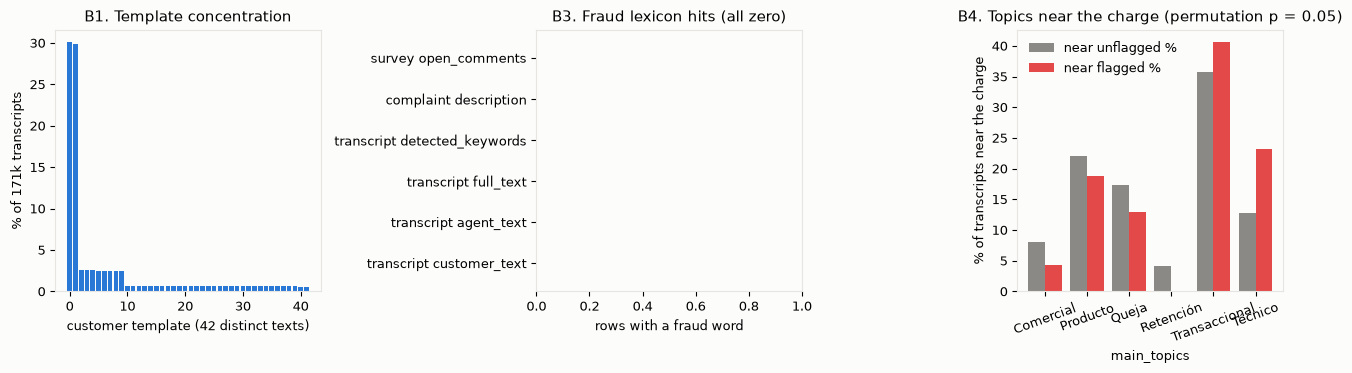

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
ax = axes[0]
share = tmpl.groupby("customer_text").n.sum().sort_values(ascending=False)
ax.bar(range(len(share)), share.values / share.sum() * 100, color=BLUE)
ax.set_xlabel("customer template (42 distinct texts)"); ax.set_ylabel("% of 171k transcripts"); ax.set_title("B1. Template concentration")
ax = axes[1]
ax.barh(lex.field, lex.fraud_hits, color=RED); ax.set_xlim(0, 1); ax.set_title("B3. Fraud lexicon hits (all zero)"); ax.set_xlabel("rows with a fraud word")
ax = axes[2]
ct2.plot.bar(ax=ax, color=[GRAY, RED], width=0.8); ax.set_ylabel("% of transcripts near the charge"); ax.set_title(f"B4. Topics near the charge (permutation p = {p:.2f})"); ax.legend(frameon=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
plt.tight_layout(); plt.savefig("notebooks/17_transcript_nlp.png", dpi=130); plt.show()

**Part B verdict.** The transcripts are 42 customer templates and 42 agent templates combined into 546 full texts, all Spanish, all balance or product enquiries, with a vocabulary of 72 words. No field in the corpus (customer text, agent text, full text, keywords, complaint descriptions, survey comments) contains a single fraud, theft, cloning, unrecognized or unauthorized word. Next to flagged charges the template and topic mix looks different only in the smallest window (69 transcripts, permutation p about 0.06); it regresses to the population mix at ±30 and ±90 days and in the interactions table, so it is sampling noise, not a signal. Sentiment and escalation rates are the same near flagged and unflagged charges. There is nothing in the calls to bring into the model.

## What this means for the model and the data

- The `is_fraud` label, the complaints table and the call transcripts were generated independently of each other and of behavior. Any supervised fraud model on this dataset can only learn the leaked `fraud_score`, which is why every leak-free experiment (notebooks 02 and 03) sits at ROC AUC 0.50.
- A claim rate metric (claims over flags) is not meaningful here: the three to one ratio is an artifact of two uniform generators.
- Text signals for the risk model would need real customer utterances. The realistic source in this product is the chat itself: Jev already types each masked message (intent, stolen card, distress), and those signals feed the policy and the profile. When real transcripts exist, the same Jev questions apply to them; the pipeline in `src/understand/` does not change.
- Filed as TQ-025 for the mentors: confirm that the label and the complaints are synthetic and independent, or point us to the linkage we missed.